# Brain MRI Images for Brain Tumor Detection
## Complete Training Pipeline with Multiple Algorithms Comparison

**Project Overview:**
- Dataset: Brain MRI Images (yes/no folders)
- Task: Binary Classification (Tumor/No Tumor)
- Models: CNN, VGG16, ResNet50, MobileNetV2, Random Forest
- Includes: Training, Comparison, Visualization, Model Saving

## 1. Import Required Libraries

In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import warnings


In [3]:
warnings.filterwarnings('ignore')
print("Num GPUs Available: ")
# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
print('tttt')
# Machine Learning Libraries


Num GPUs Available: 
tttt


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# Visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow Version: 2.19.1
GPU Available: False


## 2. Dataset Loading and Preprocessing

In [5]:
# Dataset paths - Update these paths according to your dataset location
DATASET_PATH = 'dataset'  # Main dataset folder
YES_PATH = os.path.join(DATASET_PATH, 'yes')  # Tumor images
NO_PATH = os.path.join(DATASET_PATH, 'no')   # No tumor images

# Image parameters
IMG_SIZE = 224
BATCH_SIZE = 32

# Check dataset structure
print("Dataset Structure:")
print(f"Dataset Path: {DATASET_PATH}")
print(f"Tumor Images (yes): {len(os.listdir(YES_PATH)) if os.path.exists(YES_PATH) else 0}")
print(f"No Tumor Images (no): {len(os.listdir(NO_PATH)) if os.path.exists(NO_PATH) else 0}")

Dataset Structure:
Dataset Path: dataset
Tumor Images (yes): 155
No Tumor Images (no): 98


In [6]:
# Function to load and preprocess images
def load_dataset(yes_path, no_path, img_size=224):
    """
    Load images from yes and no folders
    Returns: X (images), y (labels)
    """
    X = []
    y = []
    
    print("Loading images with tumors (yes folder)...")
    for img_name in os.listdir(yes_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(yes_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(1)  # 1 for tumor
    
    print("Loading images without tumors (no folder)...")
    for img_name in os.listdir(no_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(no_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(0)  # 0 for no tumor
    
    X = np.array(X, dtype='float32')
    y = np.array(y)
    
    print(f"\nTotal images loaded: {len(X)}")
    print(f"Images with tumor: {np.sum(y == 1)}")
    print(f"Images without tumor: {np.sum(y == 0)}")
    print(f"Image shape: {X[0].shape}")
    
    return X, y

# Load dataset
X, y = load_dataset(YES_PATH, NO_PATH, IMG_SIZE)

Loading images with tumors (yes folder)...
Loading images without tumors (no folder)...

Total images loaded: 253
Images with tumor: 155
Images without tumor: 98
Image shape: (224, 224, 3)


## 3. Data Visualization

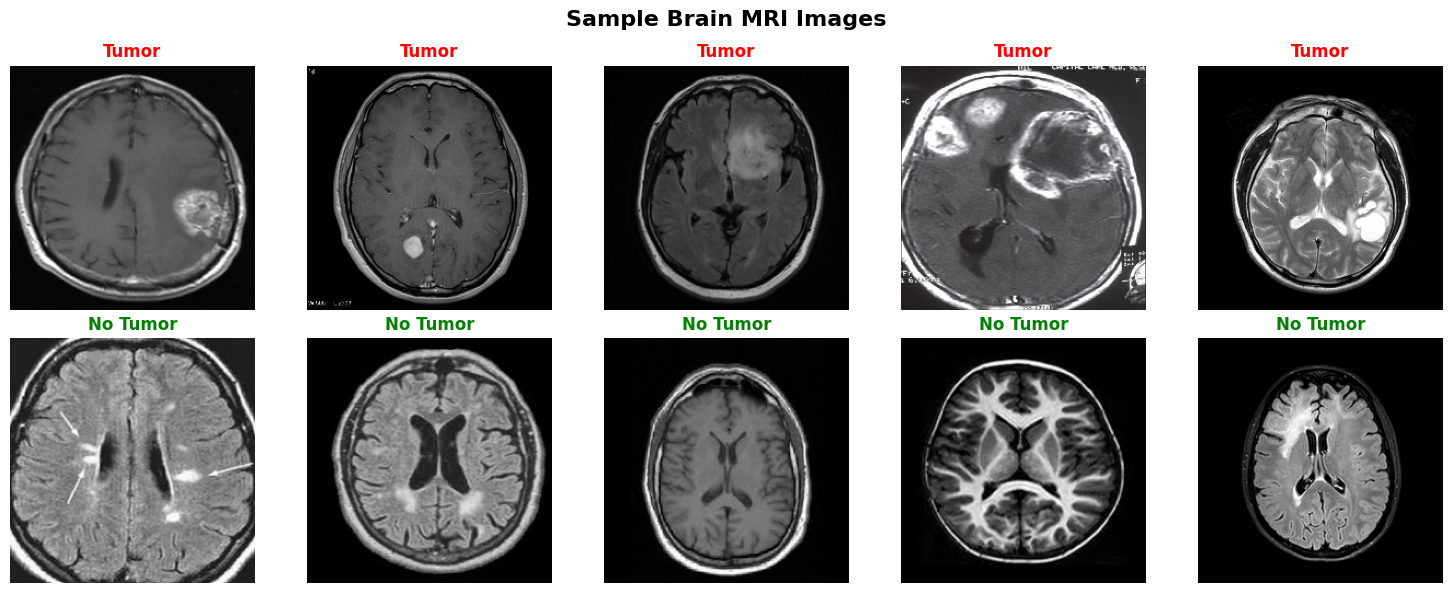

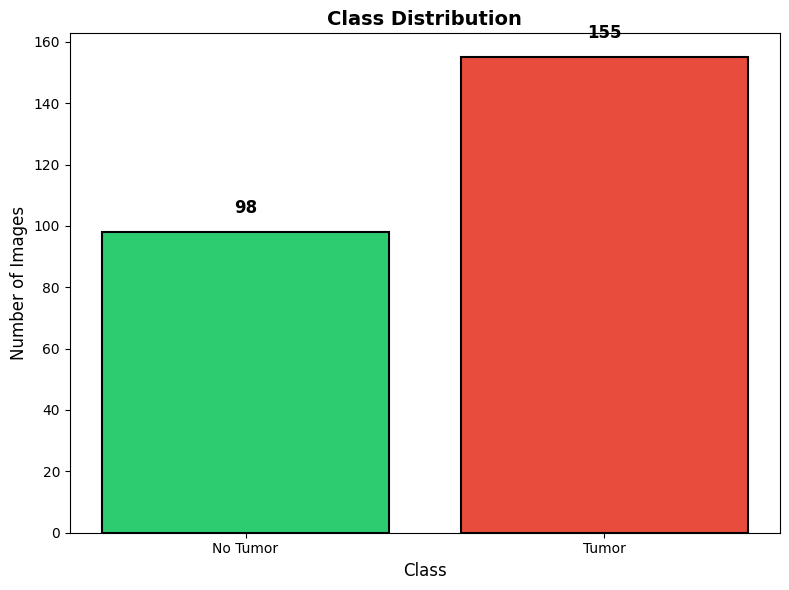

In [7]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Brain MRI Images', fontsize=16, fontweight='bold')

# Get indices for tumor and no tumor images
tumor_indices = np.where(y == 1)[0][:5]
no_tumor_indices = np.where(y == 0)[0][:5]

for i, idx in enumerate(tumor_indices):
    axes[0, i].imshow(X[idx].astype('uint8'))
    axes[0, i].set_title('Tumor', fontweight='bold', color='red')
    axes[0, i].axis('off')

for i, idx in enumerate(no_tumor_indices):
    axes[1, i].imshow(X[idx].astype('uint8'))
    axes[1, i].set_title('No Tumor', fontweight='bold', color='green')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(8, 6))
class_counts = pd.Series(y).value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
plt.bar(['No Tumor', 'Tumor'], class_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Class', fontsize=12)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Train-Test Split and Data Augmentation

In [8]:
# Normalize images
X_normalized = X / 255.0

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Dataset Split:")
print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"\nTraining set - Tumor: {np.sum(y_train == 1)}, No Tumor: {np.sum(y_train == 0)}")
print(f"Validation set - Tumor: {np.sum(y_val == 1)}, No Tumor: {np.sum(y_val == 0)}")
print(f"Test set - Tumor: {np.sum(y_test == 1)}, No Tumor: {np.sum(y_test == 0)}")

Dataset Split:
Training set: 161 images
Validation set: 41 images
Test set: 51 images

Training set - Tumor: 99, No Tumor: 62
Validation set - Tumor: 25, No Tumor: 16
Test set - Tumor: 31, No Tumor: 20


In [9]:
# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation and test
val_test_datagen = ImageDataGenerator()

print("Data augmentation configured successfully!")

Data augmentation configured successfully!


## 5. Model Building
### 5.1 Custom CNN Model

In [10]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    """
    Build Custom CNN for Brain Tumor Detection
    """
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Block 4
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Dense Layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ], name='Custom_CNN')
    
    return model

# Build and compile
cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Custom CNN Model Summary:")
cnn_model.summary()

Custom CNN Model Summary:


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 27,001,377 (103.00 MB)

 Trainable params: 26,997,921 (102.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

### 5.2 VGG16 Transfer Learning Model

In [11]:
def build_vgg16_model(input_shape=(224, 224, 3)):
    """
    Build VGG16 Transfer Learning Model
    """
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze base model layers
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    
    # Add custom layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ], name='VGG16_Transfer')
    
    return model

# Build and compile
vgg16_model = build_vgg16_model()
vgg16_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("VGG16 Model Built Successfully!")
print(f"Total parameters: {vgg16_model.count_params():,}")

VGG16 Model Built Successfully!
Total parameters: 15,112,001


### 5.3 ResNet50 Transfer Learning Model

In [12]:
def build_resnet50_model(input_shape=(224, 224, 3)):
    """
    Build ResNet50 Transfer Learning Model
    """
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze base model layers
    for layer in base_model.layers[:-10]:
        layer.trainable = False
    
    # Add custom layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ], name='ResNet50_Transfer')
    
    return model

# Build and compile
resnet_model = build_resnet50_model()
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("ResNet50 Model Built Successfully!")
print(f"Total parameters: {resnet_model.count_params():,}")

ResNet50 Model Built Successfully!
Total parameters: 24,771,457


### 5.4 MobileNetV2 Transfer Learning Model

In [13]:
def build_mobilenet_model(input_shape=(224, 224, 3)):
    """
    Build MobileNetV2 Transfer Learning Model
    """
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze base model layers
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    
    # Add custom layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ], name='MobileNetV2_Transfer')
    
    return model

# Build and compile
mobilenet_model = build_mobilenet_model()
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("MobileNetV2 Model Built Successfully!")
print(f"Total parameters: {mobilenet_model.count_params():,}")

MobileNetV2 Model Built Successfully!
Total parameters: 3,048,513


## 6. Model Training
### Training Setup

In [14]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 32

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("Training configuration set successfully!")

Training configuration set successfully!


### Train Custom CNN

In [15]:
print("=" * 50)
print("Training Custom CNN Model")
print("=" * 50)

# Check GPU availability
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Available: {len(gpus)}")
if gpus:
    print("✓ Training will use GPU (fast)")
else:
    print("⚠️ Training on CPU (will be slow)")
    print("Recommendation: Use smaller dataset or cloud GPU")

# Model checkpoint
checkpoint_cnn = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Training parameters - adjust these based on your hardware
BATCH_SIZE = 16  # Smaller batch size
EPOCHS = 30     # Fewer epochs initially

# Option 1: Direct training (RECOMMENDED - removes generator issues)
print("\nStarting training...")
history_cnn = cnn_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint_cnn],
    verbose=1
)

print("\n✓ Custom CNN Training Completed!")


Training Custom CNN Model
GPUs Available: 0
⚠️ Training on CPU (will be slow)
Recommendation: Use smaller dataset or cloud GPU

Starting training...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.6560 - loss: 0.8500 - precision: 0.7772 - recall: 0.6463
Epoch 1: val_accuracy improved from -inf to 0.39024, saving model to best_cnn_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 935ms/step - accuracy: 0.6598 - loss: 0.8504 - precision: 0.7780 - recall: 0.6513 - val_accuracy: 0.3902 - val_loss: 1.1911 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.7198 - loss: 0.6846 - precision: 0.8350 - recall: 0.7017
Epoch 2: val_accuracy did not improve from 0.39024
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 925ms/step - accuracy: 0.7188 - loss: 0.6822 - precision: 0.8312 - recall: 0.7030 - val_accuracy: 0.3902 - val_loss: 0.9061 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.8459 - loss: 0.4263 - precision: 0.8967 - recall: 0.8569
Epoch 3: val_accuracy did not improve from 0.39024
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 949ms/step - accuracy: 0.8438 - loss: 0.4291 - precision: 0.8946 - recall: 0.8545 - val_accuracy: 0.3902 - val_loss: 0.8179 - val_precision: 0.0000e+00 - val

11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8455 - loss: 0.5007 - precision: 0.9489 - recall: 0.8000 - val_accuracy: 0.6098 - val_loss: 0.6440 - val_precision: 0.6098 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.8694 - loss: 0.2626 - precision: 0.9260 - recall: 0.8641
Epoch 6: val_accuracy improved from 0.60976 to 0.78049, saving model to best_cnn_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8674 - loss: 0.2691 - precision: 0.9226 - recall: 0.8636 - val_accuracy: 0.7805 - val_loss: 0.6193 - val_precision: 0.7857 - val_recall: 0.8800 - learning_rate: 0.0010
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.8852 - loss: 0.3655 - precision: 0.9628 - recall: 0.8531
Epoch 7: val_accuracy did not improve from 0.78049
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 992ms/step - accuracy: 0.8844 - loss: 0.3649 - precision: 0.9604 - recall: 0.8536 - val_accuracy: 0.6098 - val_loss: 0.6503 - val_precision: 0.6098 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.9190 - loss: 0.2061 - precision: 0.9406 - recall: 0.9322
Epoch 8: val_accuracy did not improve from 0.78049
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 996ms/step - accuracy: 0.9180 - loss: 0.2082 - precision: 0.9389 - recall: 0.9319 - val_accuracy: 0.6098 - val_loss: 0.6412 - val_precision: 0.6098 - val_recall: 1.0000 - learn

### Train VGG16

In [16]:
print("=" * 50)
print("Training VGG16 Model")
print("=" * 50)

checkpoint_vgg16 = ModelCheckpoint(
    'best_vgg16_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_vgg16 = vgg16_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint_vgg16],
    verbose=1
)

print("\nVGG16 Training Completed!")

Training VGG16 Model
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5685 - loss: 0.8386 - precision_1: 0.6673 - recall_1: 0.5737
Epoch 1: val_accuracy improved from -inf to 0.60976, saving model to best_vgg16_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5687 - loss: 0.8419 - precision_1: 0.6672 - recall_1: 0.5764 - val_accuracy: 0.6098 - val_loss: 0.6436 - val_precision_1: 0.6098 - val_recall_1: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6842 - loss: 0.7207 - precision_1: 0.7800 - recall_1: 0.6474
Epoch 2: val_accuracy did not improve from 0.60976
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6841 - loss: 0.7170 - precision_1: 0.7823 - recall_1: 0.6465 - val_accuracy: 0.6098 - val_loss: 0.6692 - val_precision_1: 0.6098 - val_recall_1: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7357 - loss: 0.6049 - precision_1: 0.9227 - recall_1: 0.6713
Epoch 3: val_accuracy did not improve from 0.60976
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7355 - loss: 0.6027 - precision_1: 0.9159 - recall_1: 0.6734 - val_accuracy: 0.6098 - val_loss: 0.7497 - val_precision_1: 0.6098 - 

11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9096 - loss: 0.1659 - precision_1: 0.9300 - recall_1: 0.9201 - val_accuracy: 0.7317 - val_loss: 0.5776 - val_precision_1: 0.6944 - val_recall_1: 1.0000 - learning_rate: 5.0000e-05
Epoch 17/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9050 - loss: 0.3092 - precision_1: 0.9928 - recall_1: 0.8703
Epoch 17: val_accuracy improved from 0.73171 to 0.82927, saving model to best_vgg16_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9072 - loss: 0.2995 - precision_1: 0.9916 - recall_1: 0.8735 - val_accuracy: 0.8293 - val_loss: 0.3743 - val_precision_1: 0.7812 - val_recall_1: 1.0000 - learning_rate: 5.0000e-05
Epoch 18/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8946 - loss: 0.2234 - precision_1: 1.0000 - recall_1: 0.8430
Epoch 18: val_accuracy did not improve from 0.82927
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8972 - loss: 0.2197 - precision_1: 1.0000 - recall_1: 0.8460 - val_accuracy: 0.8293 - val_loss: 0.3788 - val_precision_1: 0.7812 - val_recall_1: 1.0000 - learning_rate: 5.0000e-05
Epoch 19/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9269 - loss: 0.2061 - precision_1: 0.9529 - recall_1: 0.9316
Epoch 19: val_accuracy did not improve from 0.82927
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9278 - loss: 0.2026 - precision_1: 0.9534 - recall_1: 0.9322 - val_accuracy: 0.7805 - val_loss: 0.4677 - val_precision_1: 0.735

11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9661 - loss: 0.1229 - precision_1: 0.9795 - recall_1: 0.9675 - val_accuracy: 0.8780 - val_loss: 0.3349 - val_precision_1: 0.8333 - val_recall_1: 1.0000 - learning_rate: 5.0000e-05
Epoch 21/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9642 - loss: 0.0861 - precision_1: 0.9918 - recall_1: 0.9465
Epoch 21: val_accuracy improved from 0.87805 to 0.90244, saving model to best_vgg16_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9630 - loss: 0.0880 - precision_1: 0.9907 - recall_1: 0.9459 - val_accuracy: 0.9024 - val_loss: 0.3143 - val_precision_1: 0.8889 - val_recall_1: 0.9600 - learning_rate: 5.0000e-05
Epoch 22/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9409 - loss: 0.1236 - precision_1: 0.9610 - recall_1: 0.9382
Epoch 22: val_accuracy did not improve from 0.90244
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9406 - loss: 0.1243 - precision_1: 0.9625 - recall_1: 0.9366 - val_accuracy: 0.8537 - val_loss: 0.3235 - val_precision_1: 0.8065 - val_recall_1: 1.0000 - learning_rate: 5.0000e-05
Epoch 23/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9826 - loss: 0.0797 - precision_1: 0.9980 - recall_1: 0.9736
Epoch 23: val_accuracy did not improve from 0.90244
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9804 - loss: 0.0828 - precision_1: 0.9972 - recall_1: 0.9707 - val_accuracy: 0.7561 - val_loss: 0.6687 - val_precision_1: 0.714

### Train ResNet50

In [17]:
print("=" * 50)
print("Training ResNet50 Model")
print("=" * 50)

checkpoint_resnet = ModelCheckpoint(
    'best_resnet50_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_resnet = resnet_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint_resnet],
    verbose=1
)

print("\nResNet50 Training Completed!")

Training ResNet50 Model
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.5493 - loss: 0.8857 - precision_2: 0.6400 - recall_2: 0.5878
Epoch 1: val_accuracy improved from -inf to 0.39024, saving model to best_resnet50_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 607ms/step - accuracy: 0.5501 - loss: 0.8851 - precision_2: 0.6423 - recall_2: 0.5859 - val_accuracy: 0.3902 - val_loss: 0.7202 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6336 - loss: 0.8680 - precision_2: 0.7606 - recall_2: 0.5997
Epoch 2: val_accuracy did not improve from 0.39024
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 435ms/step - accuracy: 0.6310 - loss: 0.8703 - precision_2: 0.7569 - recall_2: 0.5986 - val_accuracy: 0.3902 - val_loss: 0.7069 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7317 - loss: 0.5926 - precision_2: 0.8339 - recall_2: 0.7171
Epoch 3: val_accuracy improved from 0.39024 to 0.43902, saving model to best_resnet50_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 446ms/step - accuracy: 0.7298 - loss: 0.6050 - precision_2: 0.8319 - recall_2: 0.7146 - val_accuracy: 0.4390 - val_loss: 0.7018 - val_precision_2: 1.0000 - val_recall_2: 0.0800 - learning_rate: 1.0000e-04
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.6612 - loss: 0.6772 - precision_2: 0.7696 - recall_2: 0.6709
Epoch 4: val_accuracy improved from 0.43902 to 0.73171, saving model to best_resnet50_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 453ms/step - accuracy: 0.6599 - loss: 0.6797 - precision_2: 0.7674 - recall_2: 0.6689 - val_accuracy: 0.7317 - val_loss: 0.6686 - val_precision_2: 0.7500 - val_recall_2: 0.8400 - learning_rate: 1.0000e-04
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7398 - loss: 0.6873 - precision_2: 0.7540 - recall_2: 0.8064
Epoch 5: val_accuracy did not improve from 0.73171
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - accuracy: 0.7382 - loss: 0.6896 - precision_2: 0.7558 - recall_2: 0.8031 - val_accuracy: 0.6341 - val_loss: 0.6504 - val_precision_2: 0.6250 - val_recall_2: 1.0000 - learning_rate: 1.0000e-04
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.6834 - loss: 0.6457 - precision_2: 0.7776 - recall_2: 0.6844
Epoch 6: val_accuracy did not improve from 0.73171
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 454ms/step - accuracy: 0.6854 - loss: 0.6456 - precision_2: 0.7785 - recall_2: 0.6871 - val_accuracy: 0.6098 - val_loss: 0.6404 - val_precision_

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 537ms/step - accuracy: 0.7039 - loss: 0.5505 - precision_2: 0.7435 - recall_2: 0.7537 - val_accuracy: 0.7805 - val_loss: 0.4928 - val_precision_2: 0.7500 - val_recall_2: 0.9600 - learning_rate: 1.0000e-04
Epoch 25/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7477 - loss: 0.5715 - precision_2: 0.8158 - recall_2: 0.7588
Epoch 25: val_accuracy did not improve from 0.78049
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 530ms/step - accuracy: 0.7495 - loss: 0.5769 - precision_2: 0.8176 - recall_2: 0.7604 - val_accuracy: 0.7805 - val_loss: 0.5366 - val_precision_2: 0.7353 - val_recall_2: 1.0000 - learning_rate: 1.0000e-04
Epoch 26/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7015 - loss: 0.5687 - precision_2: 0.8094 - recall_2: 0.6704
Epoch 26: val_accuracy did not improve from 0.78049
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 510ms/step - accuracy: 0.7036 - loss: 0.5662 - precision_2: 0.8106 - recall_2: 0.6735 - val_accuracy: 0.7073 - val_loss: 0.5583 - val_precis

### Train MobileNetV2

In [18]:
print("=" * 50)
print("Training MobileNetV2 Model")
print("=" * 50)

checkpoint_mobilenet = ModelCheckpoint(
    'best_mobilenet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_mobilenet = mobilenet_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint_mobilenet],
    verbose=1
)

print("\nMobileNetV2 Training Completed!")

Training MobileNetV2 Model
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5247 - loss: 0.9746 - precision_3: 0.6089 - recall_3: 0.5741
Epoch 1: val_accuracy improved from -inf to 0.46341, saving model to best_mobilenet_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.5265 - loss: 0.9732 - precision_3: 0.6127 - recall_3: 0.5725 - val_accuracy: 0.4634 - val_loss: 0.7439 - val_precision_3: 1.0000 - val_recall_3: 0.1200 - learning_rate: 1.0000e-04
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6036 - loss: 0.7145 - precision_3: 0.6751 - recall_3: 0.6325
Epoch 2: val_accuracy improved from 0.46341 to 0.51220, saving model to best_mobilenet_model.h5


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.6076 - loss: 0.7116 - precision_3: 0.6816 - recall_3: 0.6336 - val_accuracy: 0.5122 - val_loss: 0.7965 - val_precision_3: 1.0000 - val_recall_3: 0.2000 - learning_rate: 1.0000e-04
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7510 - loss: 0.5700 - precision_3: 0.8670 - recall_3: 0.7366 
Epoch 3: val_accuracy did not improve from 0.51220
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.7532 - loss: 0.5654 - precision_3: 0.8659 - recall_3: 0.7392 - val_accuracy: 0.5122 - val_loss: 0.8308 - val_precision_3: 1.0000 - val_recall_3: 0.2000 - learning_rate: 1.0000e-04
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7668 - loss: 0.4474 - precision_3: 0.8847 - recall_3: 0.7048
Epoch 4: val_accuracy did not improve from 0.51220
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.7682 - loss: 0.4512 - precision_3: 0.8852 - recall_3: 0.7075 - val_accuracy: 0.5122 - val_loss: 0.8520 - val_precision_3

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.8822 - loss: 0.3012 - precision_3: 0.9480 - recall_3: 0.8640 - val_accuracy: 0.5366 - val_loss: 0.9109 - val_precision_3: 1.0000 - val_recall_3: 0.2400 - learning_rate: 5.0000e-05
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9143 - loss: 0.2633 - precision_3: 0.9768 - recall_3: 0.8811
Epoch 10: val_accuracy did not improve from 0.53659
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.9126 - loss: 0.2657 - precision_3: 0.9742 - recall_3: 0.8809 - val_accuracy: 0.5366 - val_loss: 0.9267 - val_precision_3: 1.0000 - val_recall_3: 0.2400 - learning_rate: 5.0000e-05
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7876 - loss: 0.2833 - precision_3: 0.8105 - recall_3: 0.7984  
Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 11: val_accuracy did not improve from 0.53659
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.7944 - loss: 0.2785 - precision_3: 

## 7. Traditional Machine Learning Models
### Random Forest with Feature Extraction

In [19]:
print("=" * 50)
print("Training Random Forest Model")
print("=" * 50)

# Flatten images for traditional ML
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Apply PCA for dimensionality reduction
print("Applying PCA for feature extraction...")
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca = pca.transform(X_val_flat)
X_test_pca = pca.transform(X_test_flat)

print(f"Explained variance ratio: {np.sum(pca.explained_variance_ratio_):.4f}")

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nTraining Random Forest...")
rf_model.fit(X_train_pca, y_train)

# Validation accuracy
rf_val_pred = rf_model.predict(X_val_pca)
rf_val_accuracy = accuracy_score(y_val, rf_val_pred)

print(f"\nRandom Forest Validation Accuracy: {rf_val_accuracy:.4f}")
print("Random Forest Training Completed!")

Training Random Forest Model
Applying PCA for feature extraction...
Explained variance ratio: 0.9506

Training Random Forest...

Random Forest Validation Accuracy: 0.8537
Random Forest Training Completed!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


## 8. Model Evaluation on Test Set

In [20]:
def evaluate_model(model, X_test, y_test, model_name, is_dl=True):
    """
    Evaluate model and return metrics
    """
    if is_dl:
        y_pred_prob = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{'=' * 50}")
    print(f"{model_name} - Test Set Evaluation")
    print(f"{'=' * 50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob
    }

# Evaluate all models
results = []

results.append(evaluate_model(cnn_model, X_test, y_test, 'Custom CNN'))
results.append(evaluate_model(vgg16_model, X_test, y_test, 'VGG16'))
results.append(evaluate_model(resnet_model, X_test, y_test, 'ResNet50'))
results.append(evaluate_model(mobilenet_model, X_test, y_test, 'MobileNetV2'))
results.append(evaluate_model(rf_model, X_test_pca, y_test, 'Random Forest', is_dl=False))

print("\n" + "=" * 50)
print("All Models Evaluated Successfully!")
print("=" * 50)


Custom CNN - Test Set Evaluation
Accuracy:  0.6667
Precision: 0.7333
Recall:    0.7097
F1-Score:  0.7213

VGG16 - Test Set Evaluation
Accuracy:  0.8431
Precision: 0.8108
Recall:    0.9677
F1-Score:  0.8824



ResNet50 - Test Set Evaluation
Accuracy:  0.6863
Precision: 0.6596
Recall:    1.0000
F1-Score:  0.7949

MobileNetV2 - Test Set Evaluation
Accuracy:  0.4118
Precision: 1.0000
Recall:    0.0323
F1-Score:  0.0625

Random Forest - Test Set Evaluation
Accuracy:  0.8235
Precision: 0.7750
Recall:    1.0000
F1-Score:  0.8732

All Models Evaluated Successfully!


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


## 9. Results Comparison and Visualization

In [21]:
# Create comparison dataframe
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1_score']]
comparison_df = comparison_df.sort_values('accuracy', ascending=False)

print("\n" + "=" * 80)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Save comparison
comparison_df.to_csv('model_comparison.csv', index=False)
print("\nComparison saved to 'model_comparison.csv'")


MODEL COMPARISON - TEST SET PERFORMANCE
        model  accuracy  precision   recall  f1_score
        VGG16  0.843137   0.810811 0.967742  0.882353
Random Forest  0.823529   0.775000 1.000000  0.873239
     ResNet50  0.686275   0.659574 1.000000  0.794872
   Custom CNN  0.666667   0.733333 0.709677  0.721311
  MobileNetV2  0.411765   1.000000 0.032258  0.062500

Comparison saved to 'model_comparison.csv'


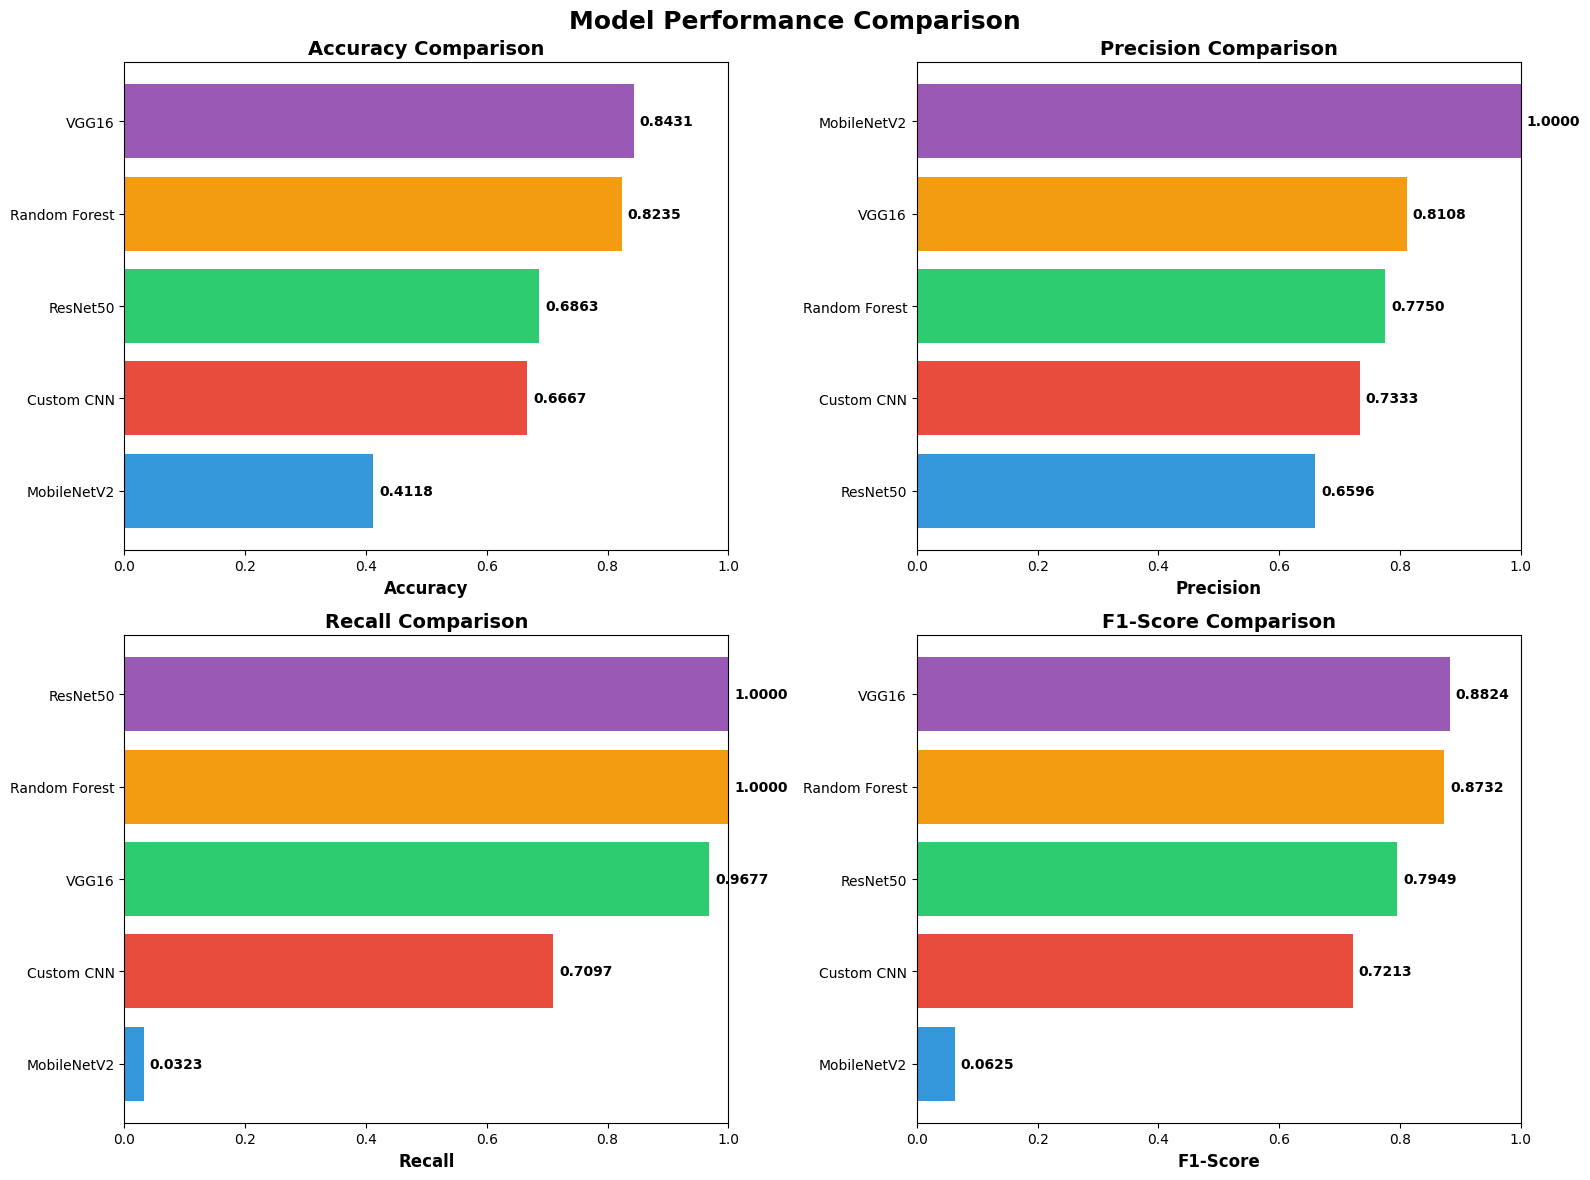

In [22]:
# Visualization 1: Bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    data = comparison_df.sort_values(metric, ascending=True)
    bars = ax.barh(data['model'], data[metric], color=colors_palette)
    ax.set_xlabel(title, fontsize=12, fontweight='bold')
    ax.set_title(f'{title} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1])
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, data[metric])):
        ax.text(value + 0.01, i, f'{value:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=300, bbox_inches='tight')
plt.show()

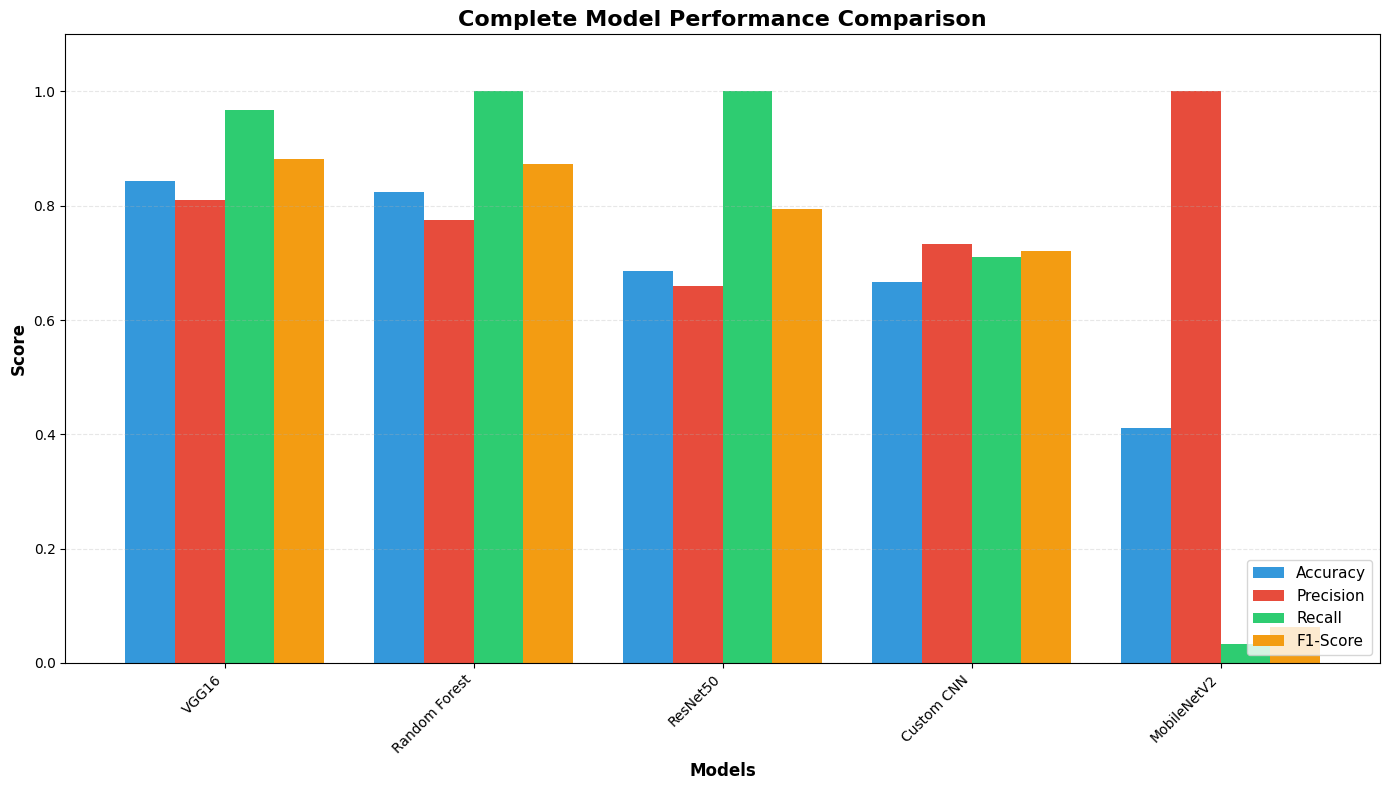

In [23]:
# Visualization 2: Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(comparison_df))
width = 0.2

bars1 = ax.bar(x - 1.5*width, comparison_df['accuracy'], width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x - 0.5*width, comparison_df['precision'], width, label='Precision', color='#e74c3c')
bars3 = ax.bar(x + 0.5*width, comparison_df['recall'], width, label='Recall', color='#2ecc71')
bars4 = ax.bar(x + 1.5*width, comparison_df['f1_score'], width, label='F1-Score', color='#f39c12')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Complete Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['model'], rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('model_comparison_grouped.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Confusion Matrices

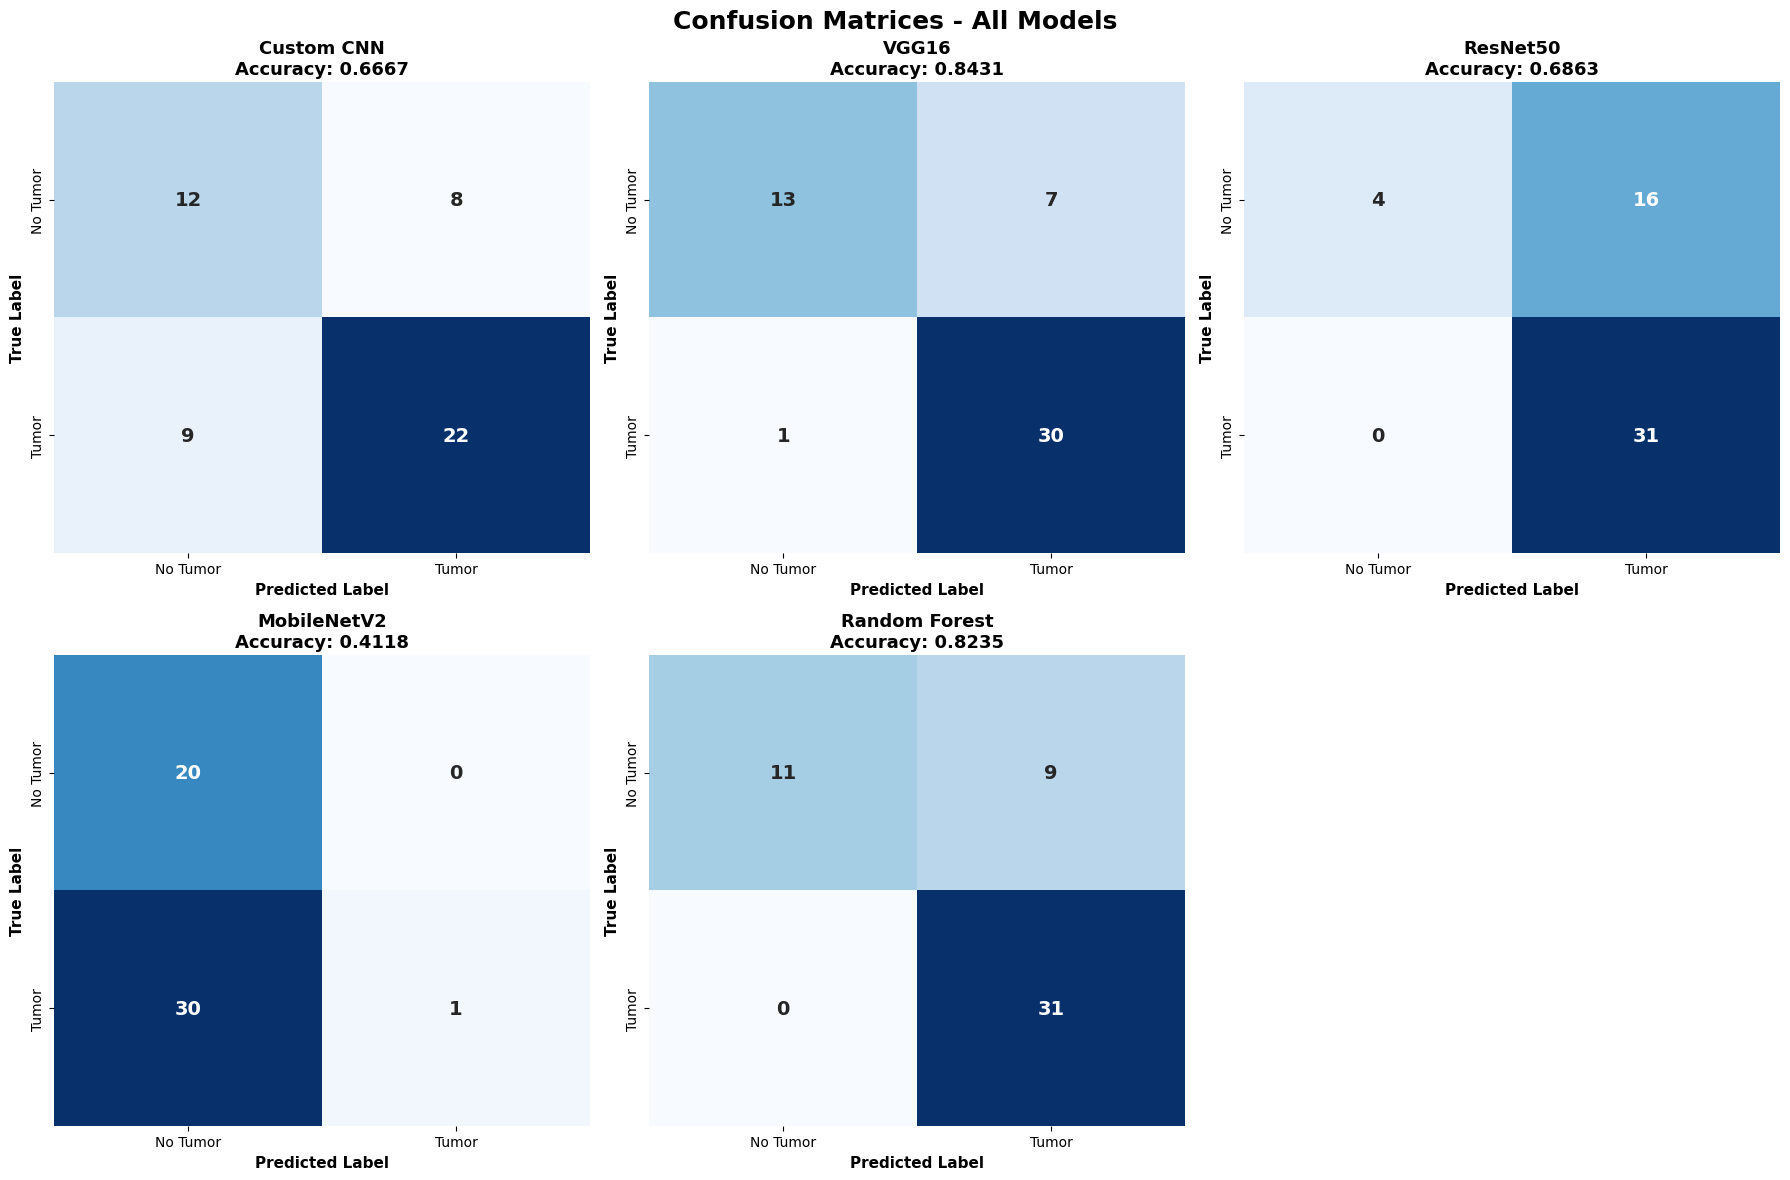

In [24]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=18, fontweight='bold')

for idx, result in enumerate(results):
    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(y_test, result['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No Tumor', 'Tumor'],
                yticklabels=['No Tumor', 'Tumor'],
                annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_title(f"{result['model']}\nAccuracy: {result['accuracy']:.4f}", 
                fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

# Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. ROC Curves

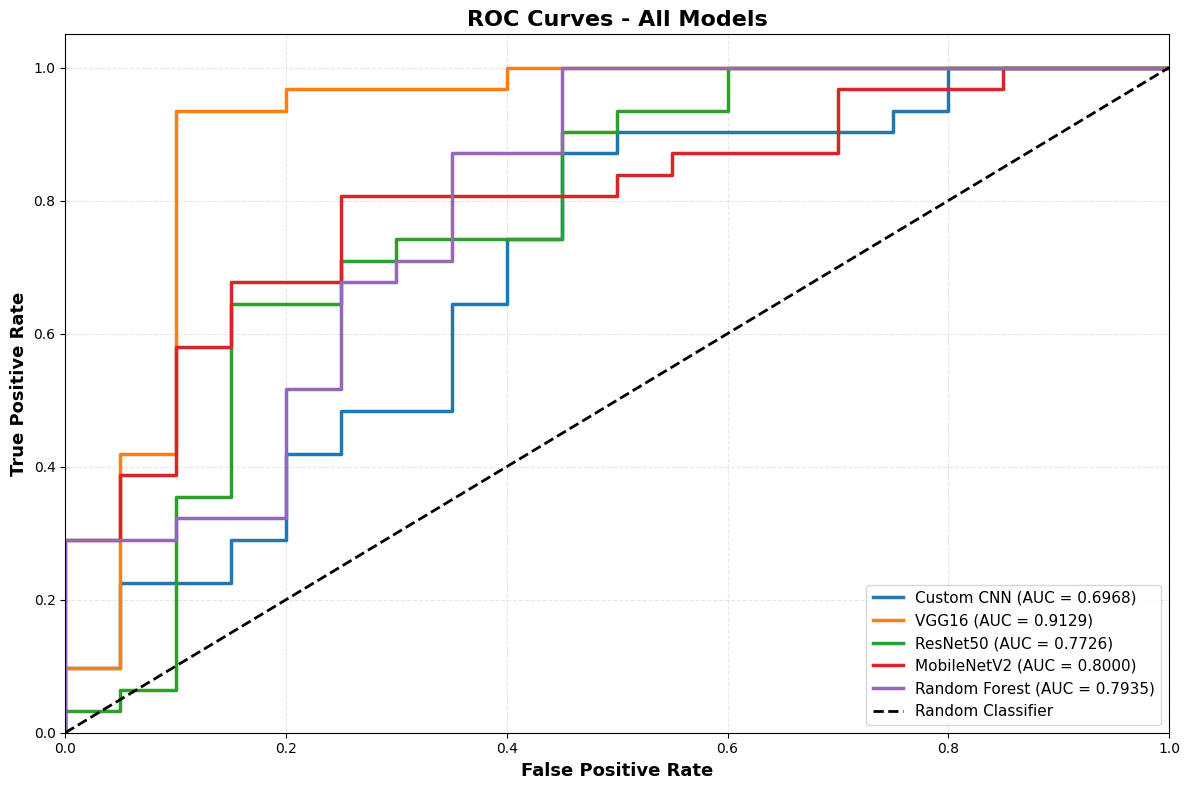

In [25]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for result in results:
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2.5, 
            label=f"{result['model']} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Training History Visualization

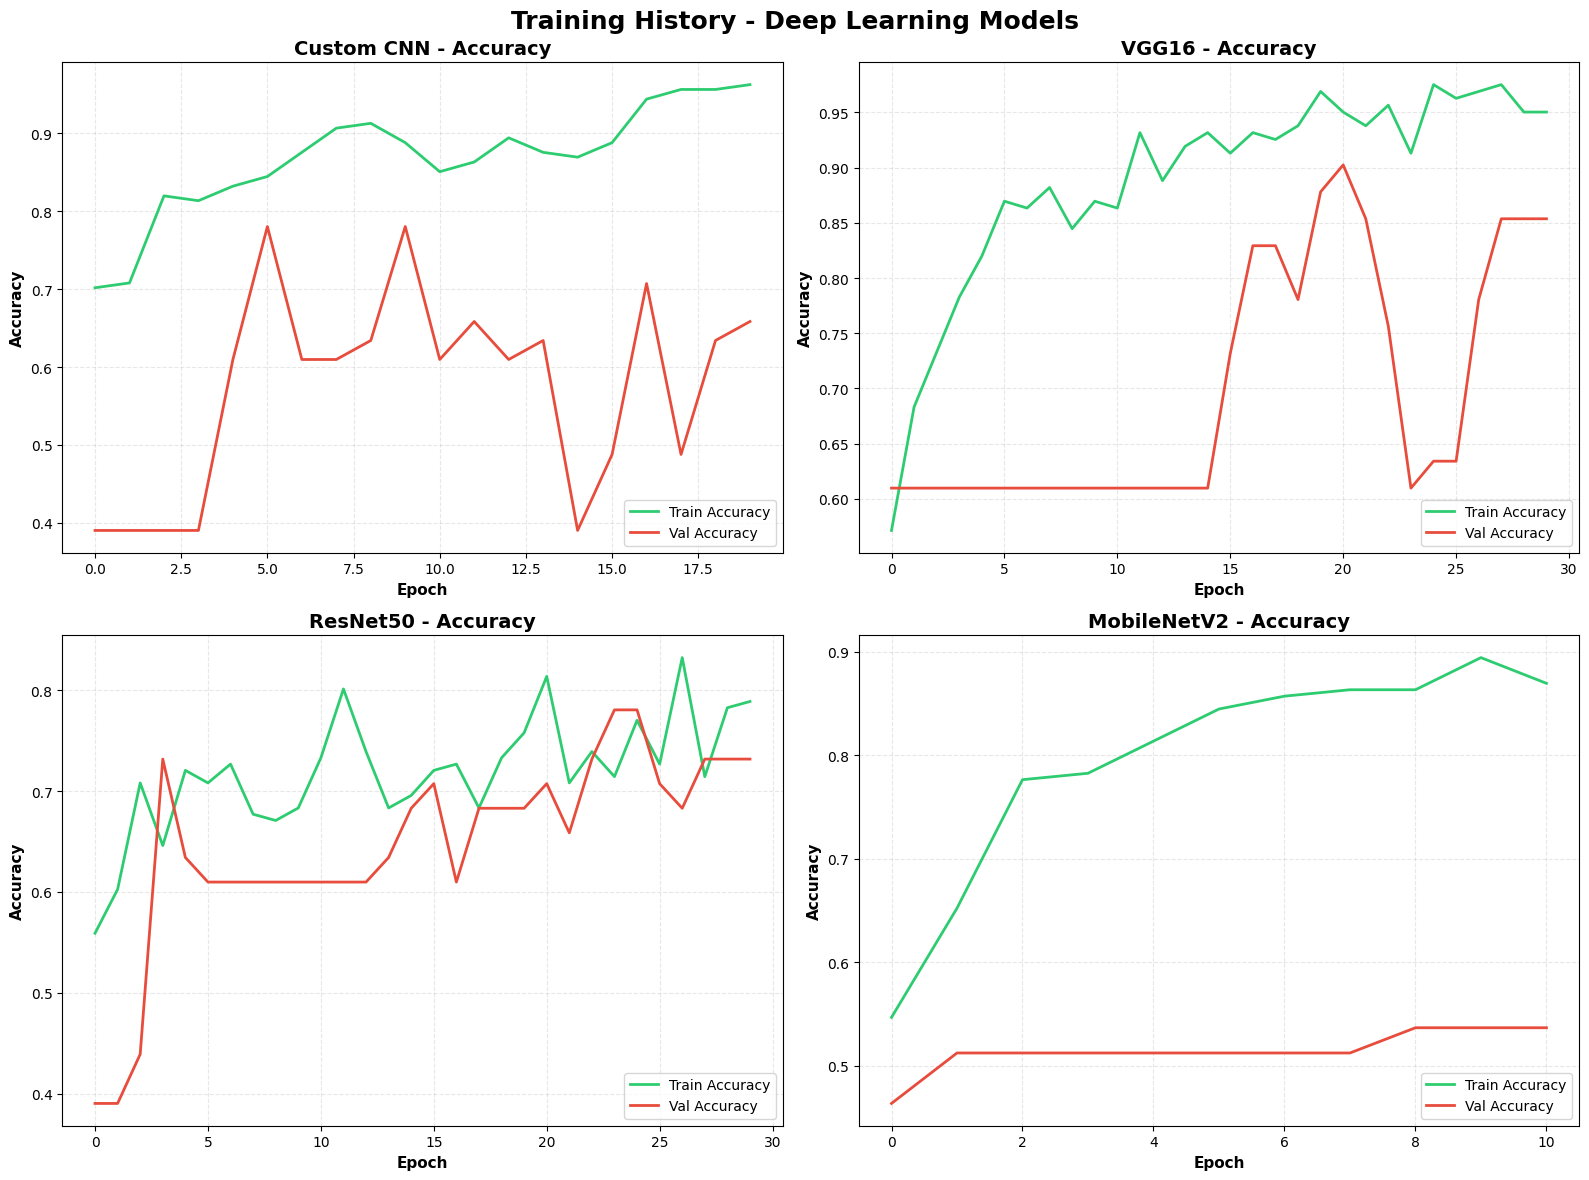

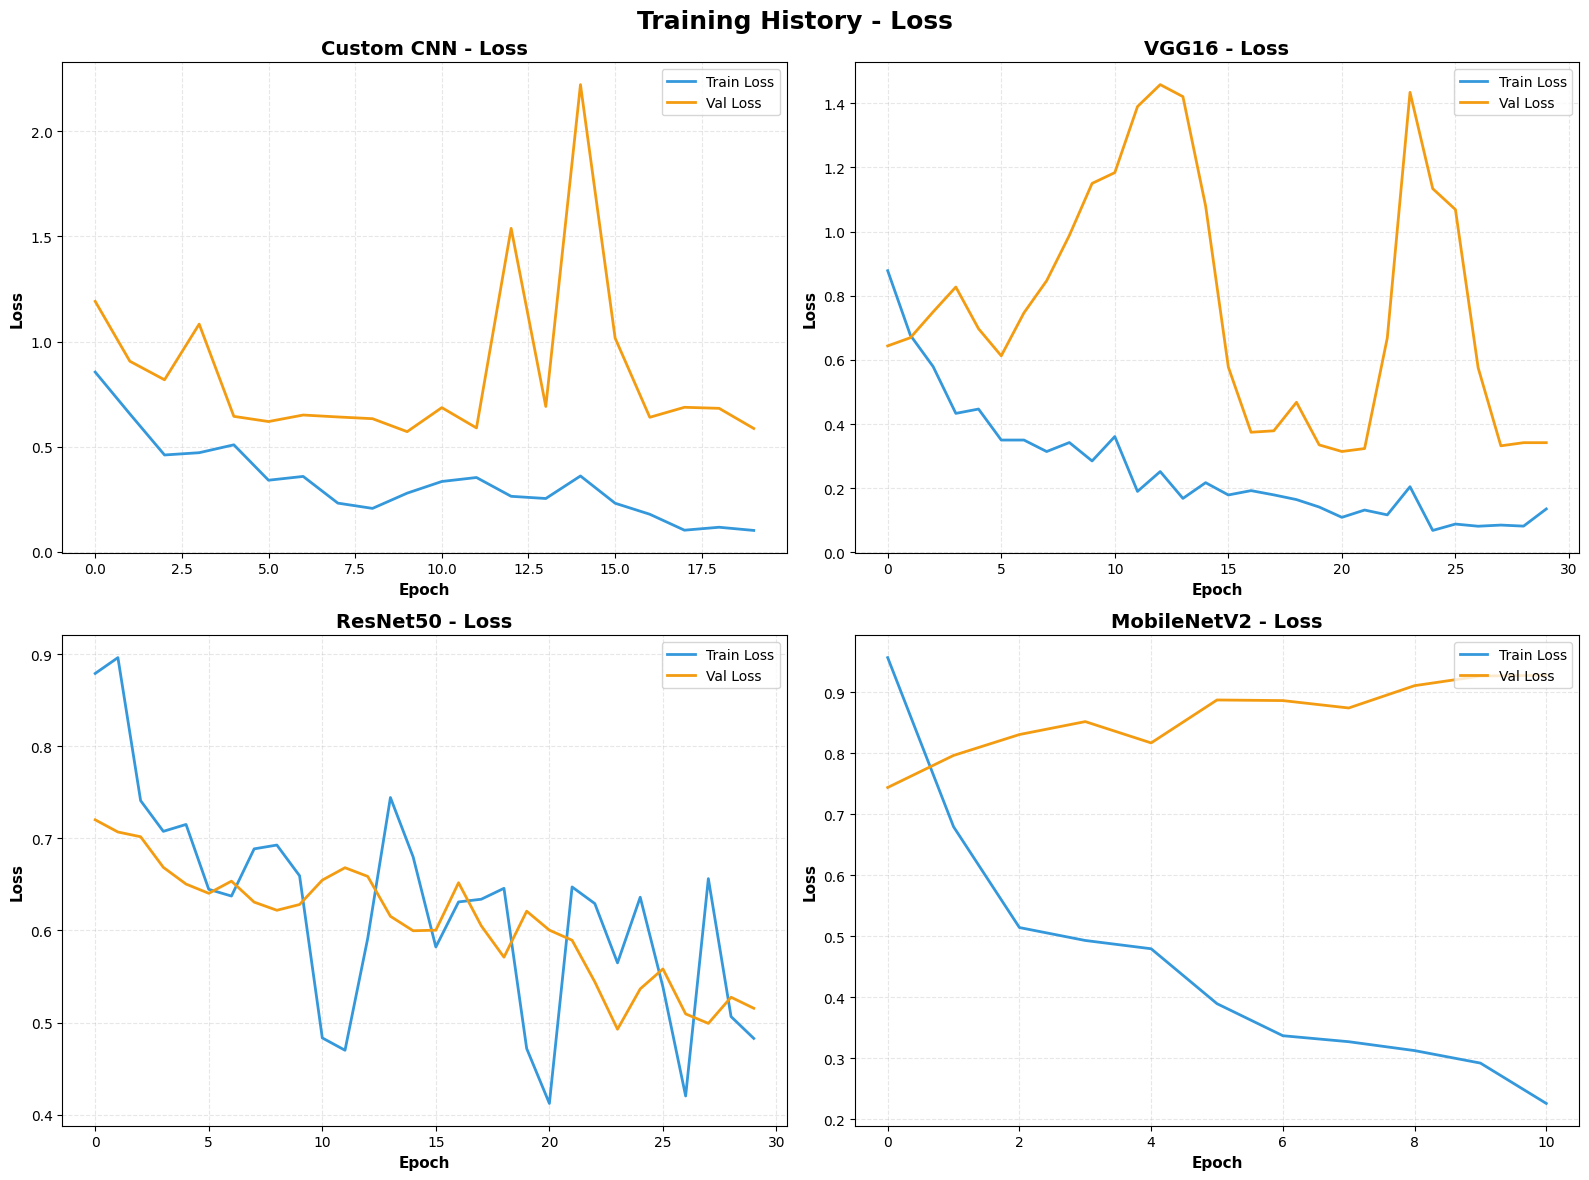

In [26]:
# Plot training history for deep learning models
histories = [
    (history_cnn, 'Custom CNN'),
    (history_vgg16, 'VGG16'),
    (history_resnet, 'ResNet50'),
    (history_mobilenet, 'MobileNetV2')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training History - Deep Learning Models', fontsize=18, fontweight='bold')

for idx, (history, model_name) in enumerate(histories):
    ax = axes[idx // 2, idx % 2]
    
    # Plot accuracy
    ax.plot(history.history['accuracy'], linewidth=2, label='Train Accuracy', color='#2ecc71')
    ax.plot(history.history['val_accuracy'], linewidth=2, label='Val Accuracy', color='#e74c3c')
    
    ax.set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('training_history_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot loss
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training History - Loss', fontsize=18, fontweight='bold')

for idx, (history, model_name) in enumerate(histories):
    ax = axes[idx // 2, idx % 2]
    
    # Plot loss
    ax.plot(history.history['loss'], linewidth=2, label='Train Loss', color='#3498db')
    ax.plot(history.history['val_loss'], linewidth=2, label='Val Loss', color='#f39c12')
    
    ax.set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('training_history_loss.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Prediction Examples


Best Model: VGG16
Test Accuracy: 0.8431


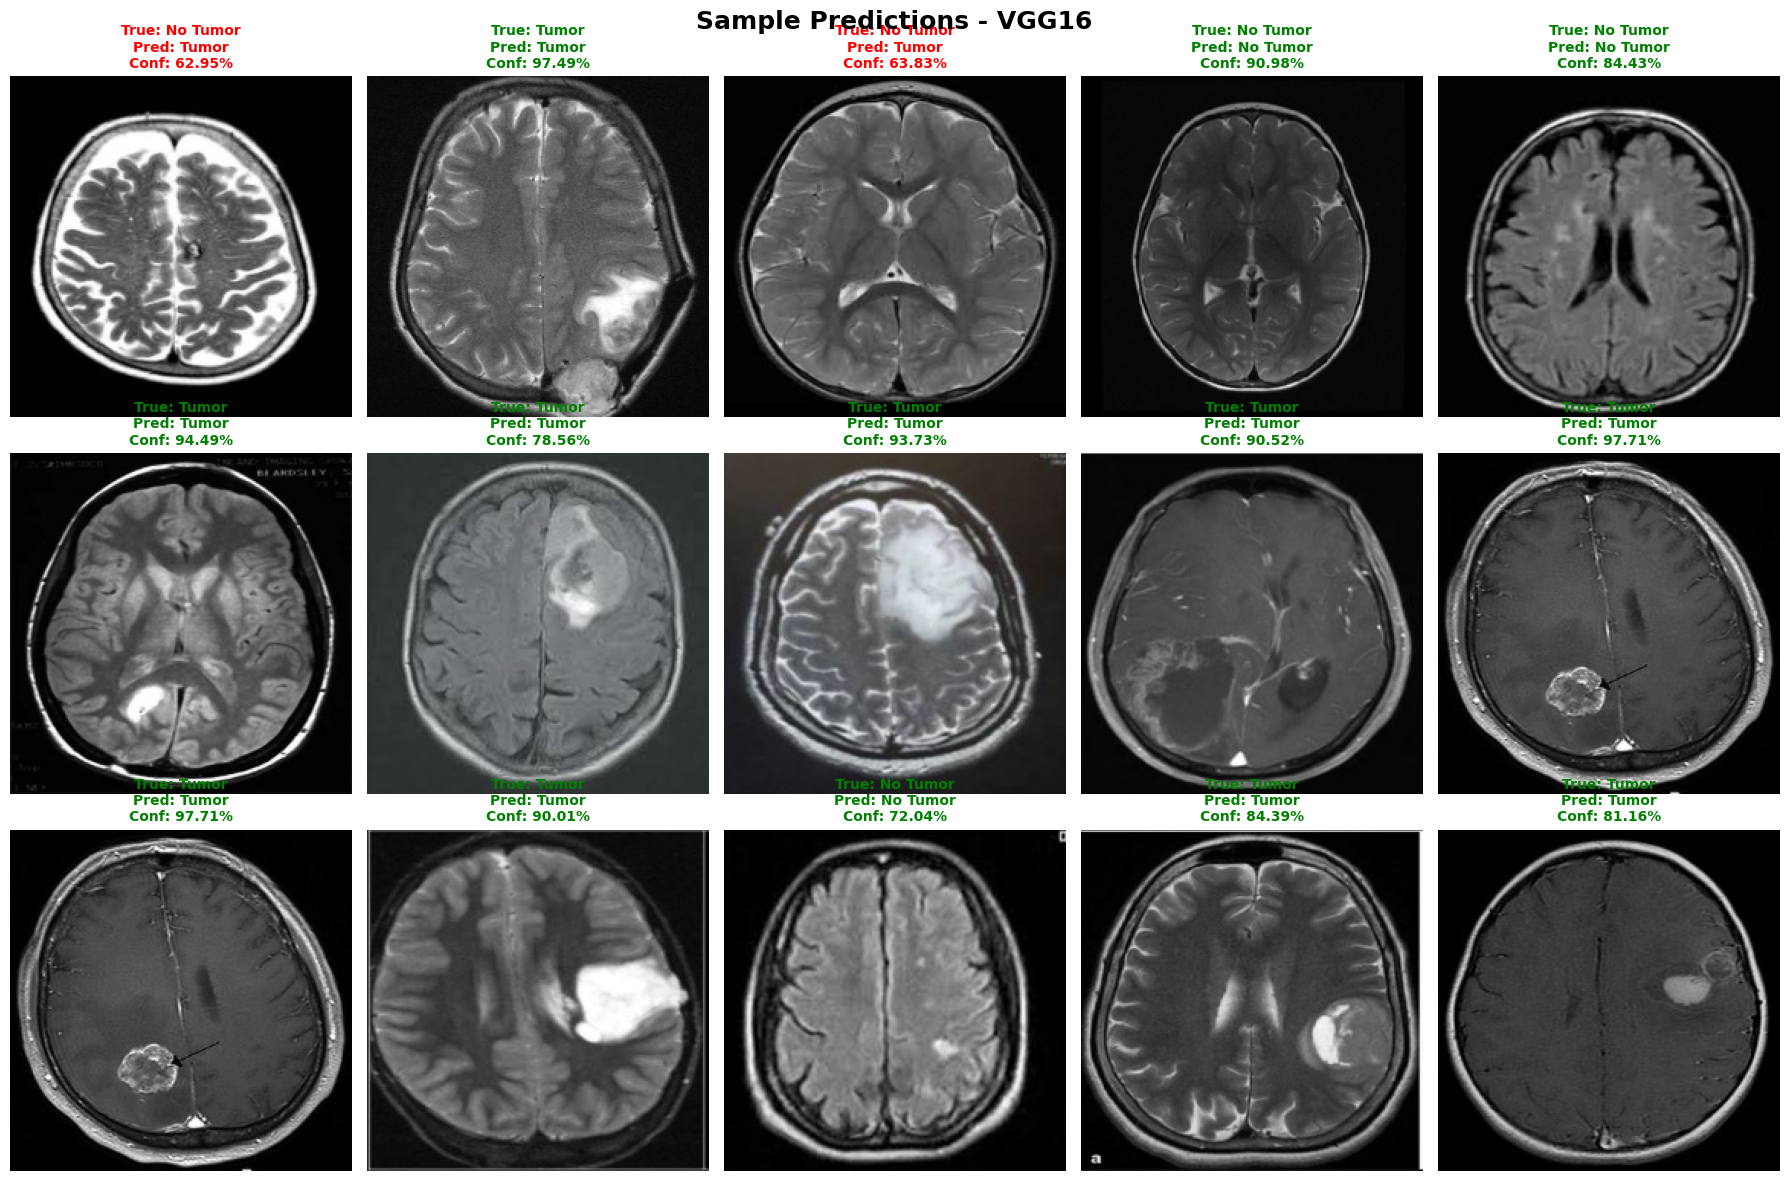

In [27]:
# Show predictions on test images (using best model)
best_model_idx = np.argmax([r['accuracy'] for r in results])
best_model_name = results[best_model_idx]['model']
best_predictions = results[best_model_idx]['y_pred']
best_probs = results[best_model_idx]['y_pred_prob']

print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {results[best_model_idx]['accuracy']:.4f}")

# Visualize predictions
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
fig.suptitle(f'Sample Predictions - {best_model_name}', fontsize=18, fontweight='bold')

# Get random samples
random_indices = np.random.choice(len(X_test), 15, replace=False)

for idx, test_idx in enumerate(random_indices):
    ax = axes[idx // 5, idx % 5]
    
    # Display image
    ax.imshow(X_test[test_idx])
    
    # Get prediction
    true_label = 'Tumor' if y_test[test_idx] == 1 else 'No Tumor'
    pred_label = 'Tumor' if best_predictions[test_idx] == 1 else 'No Tumor'
    confidence = best_probs[test_idx] if best_predictions[test_idx] == 1 else (1 - best_probs[test_idx])
    
    # Color based on correctness
    color = 'green' if true_label == pred_label else 'red'
    
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2%}',
                fontsize=10, fontweight='bold', color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('prediction_examples.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Model Saving

In [28]:
# Save all models
print("Saving all trained models...\n")

# Save deep learning models
cnn_model.save('final_custom_cnn_model.h5')
print("✓ Custom CNN model saved as 'final_custom_cnn_model.h5'")

vgg16_model.save('final_vgg16_model.h5')
print("✓ VGG16 model saved as 'final_vgg16_model.h5'")

resnet_model.save('final_resnet50_model.h5')
print("✓ ResNet50 model saved as 'final_resnet50_model.h5'")

mobilenet_model.save('final_mobilenet_model.h5')
print("✓ MobileNetV2 model saved as 'final_mobilenet_model.h5'")

# Save Random Forest and PCA
import pickle

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✓ Random Forest model saved as 'random_forest_model.pkl'")

with open('pca_transformer.pkl', 'wb') as f:
    pickle.dump(pca, f)
print("✓ PCA transformer saved as 'pca_transformer.pkl'")

print("\nAll models saved successfully!")

Saving all trained models...



✓ Custom CNN model saved as 'final_custom_cnn_model.h5'
✓ VGG16 model saved as 'final_vgg16_model.h5'


✓ ResNet50 model saved as 'final_resnet50_model.h5'
✓ MobileNetV2 model saved as 'final_mobilenet_model.h5'
✓ Random Forest model saved as 'random_forest_model.pkl'
✓ PCA transformer saved as 'pca_transformer.pkl'

All models saved successfully!


## 15. Summary and Final Report

In [29]:
print("\n" + "="*80)
print("BRAIN TUMOR DETECTION PROJECT - FINAL SUMMARY")
print("="*80)

print("\n📊 DATASET INFORMATION:")
print(f"   Total Images: {len(X)}")
print(f"   Training Set: {len(X_train)}")
print(f"   Validation Set: {len(X_val)}")
print(f"   Test Set: {len(X_test)}")
print(f"   Image Size: {IMG_SIZE}x{IMG_SIZE}")

print("\n🤖 MODELS TRAINED:")
for i, result in enumerate(results, 1):
    print(f"   {i}. {result['model']}")

print("\n🏆 BEST MODEL:")
best_idx = comparison_df.index[0]
best_row = comparison_df.iloc[0]
print(f"   Model: {best_row['model']}")
print(f"   Accuracy: {best_row['accuracy']:.4f}")
print(f"   Precision: {best_row['precision']:.4f}")
print(f"   Recall: {best_row['recall']:.4f}")
print(f"   F1-Score: {best_row['f1_score']:.4f}")

print("\n📈 TOP 3 MODELS BY ACCURACY:")
for idx, row in comparison_df.head(3).iterrows():
    print(f"   {row['model']}: {row['accuracy']:.4f}")

print("\n💾 SAVED FILES:")
print("   - final_custom_cnn_model.h5")
print("   - final_vgg16_model.h5")
print("   - final_resnet50_model.h5")
print("   - final_mobilenet_model.h5")
print("   - random_forest_model.pkl")
print("   - pca_transformer.pkl")
print("   - model_comparison.csv")
print("   - Various visualization images")

print("\n" + "="*80)
print("PROJECT COMPLETED SUCCESSFULLY! ✓")
print("="*80)


BRAIN TUMOR DETECTION PROJECT - FINAL SUMMARY

📊 DATASET INFORMATION:
   Total Images: 253
   Training Set: 161
   Validation Set: 41
   Test Set: 51
   Image Size: 224x224

🤖 MODELS TRAINED:
   1. Custom CNN
   2. VGG16
   3. ResNet50
   4. MobileNetV2
   5. Random Forest

🏆 BEST MODEL:
   Model: VGG16
   Accuracy: 0.8431
   Precision: 0.8108
   Recall: 0.9677
   F1-Score: 0.8824

📈 TOP 3 MODELS BY ACCURACY:
   VGG16: 0.8431
   Random Forest: 0.8235
   ResNet50: 0.6863

💾 SAVED FILES:
   - final_custom_cnn_model.h5
   - final_vgg16_model.h5
   - final_resnet50_model.h5
   - final_mobilenet_model.h5
   - random_forest_model.pkl
   - pca_transformer.pkl
   - model_comparison.csv
   - Various visualization images

PROJECT COMPLETED SUCCESSFULLY! ✓


## 16. Prediction Function for New Images

In [30]:
def predict_brain_tumor(image_path, model, img_size=224):
    """
    Predict if a brain MRI image contains tumor
    
    Args:
        image_path: Path to the MRI image
        model: Trained model (keras model)
        img_size: Image size for preprocessing
    
    Returns:
        prediction, confidence
    """
    # Load and preprocess image
    img = cv2.imread(image_path)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    
    # Predict
    prediction_prob = model.predict(img, verbose=0)[0][0]
    prediction = 'Tumor Detected' if prediction_prob > 0.5 else 'No Tumor'
    confidence = prediction_prob if prediction_prob > 0.5 else (1 - prediction_prob)
    
    return prediction, confidence

# Example usage (uncomment to use)
# prediction, confidence = predict_brain_tumor('path/to/your/image.jpg', cnn_model)
# print(f"Prediction: {prediction}")
# print(f"Confidence: {confidence:.2%}")

print("Prediction function defined successfully!")
print("Use: predict_brain_tumor('image_path', model)")

Prediction function defined successfully!
Use: predict_brain_tumor('image_path', model)
